# Gold/USD Daily Close Predictor - a mentor-style walkthrough

This notebook is written like someone is sitting next to you explaining
each step *before* you take it, not a polished report you'd hand in cold.
That's on purpose - the "why" behind each step is the part that actually
transfers to your next project. The code is the easy part.

**The problem we're solving:** can a Random Forest Regressor, trained on
price action, technical indicators, macro-event flags, and news sentiment,
predict tomorrow's XAU/USD (Gold/USD) daily close well enough to beat a
naive guess?

**A promise upfront:** gold is close to a random walk on a daily horizon.
If our model barely beats "tomorrow = today," that's not a failed
project - that's a *finding*, and it's worth writing about honestly
instead of hiding it.

**A note on data, read this before anything else:** TradingView doesn't
offer a free public API for historical data - export is manual CSV only.
ForexFactory and Investing.com both discourage scraping in their terms of
service. So instead of quietly pretending this notebook pulls live data,
it runs on **realistic synthetic data** that mimics gold's real
statistical behavior (volatility clustering, mild drift, occasional
macro-event shocks). Every place you'd swap in your real TradingView
export or ForexFactory calendar pull is marked clearly with `# REAL DATA
GOES HERE`, so upgrading this later is a copy-paste job, not a rewrite.

---

### The roadmap
1. Data collection (and what "real" collection would look like)
2. Exploratory Data Analysis - get a feel for the data before touching a model
3. Feature engineering - turn raw price into signal
4. Time-aware train/test split
5. Baseline model - the honesty check
6. Random Forest training
7. Evaluation - did we actually learn anything?
8. Feature importance - what is the model actually using?
9. Reflection - limitations and what "real" would change


## Step 1: Data Collection

**Why this step matters first:** every mistake downstream - a leaky
feature, a wrong metric, an overconfident conclusion - traces back to a
decision made here. Before writing a line of model code, you need to know
exactly what your rows and columns represent, and where they'd come from
in the real world.

**What "real" collection looks like for this project:**
- **Price data (OHLCV):** manually export daily XAUUSD bars from a
  TradingView chart as CSV (up to 5,000 bars per export, free accounts).
- **Macro events:** ForexFactory's economic calendar (CSV/manual pull),
  filtered to high-impact USD events - NFP, CPI, FOMC rate decisions.
  These move gold because gold trades inversely to real interest rate
  expectations.
- **News sentiment:** a legitimate news API (NewsAPI, GDELT) run through
  a sentiment scorer, standing in for the Investing.com angle since that
  site actively blocks scraping.

Below, we generate synthetic data shaped like all three, so the full
pipeline runs end-to-end. The generation logic isn't arbitrary - it's
built to mimic two real properties of gold: **volatility clustering**
(calm stretches followed by choppy ones - this is why we simulate
volatility as its own slow-moving process, not just noise) and
**occasional event shocks** (macro releases cause bigger-than-usual
moves).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

np.random.seed(42)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
# --- SYNTHETIC PRICE DATA (stand-in for a real TradingView export) ---
# REAL DATA GOES HERE: replace this whole cell with
#   df = pd.read_csv("data/XAUUSD_tradingview_export.csv", parse_dates=["date"])

n_days = 900
dates = pd.bdate_range(start="2022-01-03", periods=n_days)  # business days only, like a real market

# Volatility as its own slow-moving process (this is what "clustering" means:
# today's volatility depends on yesterday's, not on nothing).
vol = np.zeros(n_days)
vol[0] = 0.008
for t in range(1, n_days):
    vol[t] = 0.05 * 0.008 + 0.9 * vol[t - 1] + 0.05 * abs(np.random.normal(0, 0.01))

drift = 0.0003  # small persistent upward drift, gold has trended up over most multi-year windows
shocks = np.random.normal(0, 1, n_days)
returns = drift + vol * shocks

# Macro "event days" get an extra shock on top of the normal day - this is
# what a real NFP or CPI surprise does to gold.
event_days = np.random.choice(n_days, size=int(n_days * 0.05), replace=False)
high_impact_event = np.zeros(n_days, dtype=int)
high_impact_event[event_days] = 1
returns[event_days] += np.random.normal(0, 0.012, size=len(event_days))

close = 1800 * np.exp(np.cumsum(returns))

daily_range = np.abs(np.random.normal(0, 1, n_days)) * vol * close
open_ = close * (1 + np.random.normal(0, 0.001, n_days))
high = np.maximum(open_, close) + daily_range * 0.5
low = np.minimum(open_, close) - daily_range * 0.5
volume = np.random.randint(80_000, 250_000, n_days)

df = pd.DataFrame({
    "date": dates,
    "open": open_, "high": high, "low": low, "close": close,
    "volume": volume, "high_impact_event": high_impact_event,
})

# --- SYNTHETIC NEWS SENTIMENT (stand-in for a real NewsAPI/GDELT pull) ---
# REAL DATA GOES HERE: replace with a daily aggregate sentiment score,
# e.g. mean VADER compound score across that day's gold/macro headlines.
# We generate this as PURE NOISE on purpose - watch for it in Step 8.
df["news_sentiment"] = np.random.normal(0, 0.3, n_days).clip(-1, 1)

df = df.set_index("date")
print(f"{len(df)} trading days, {df.index.min().date()} to {df.index.max().date()}")
df.head()

900 trading days, 2022-01-03 to 2025-06-13


,open,high,low,close,volume,high_impact_event,news_sentiment
date,,,,,,,
2022-01-03,1788.519698,1793.650210,1783.680534,1788.811047,211778,0,-0.023274
2022-01-04,1819.691429,1822.589456,1818.709578,1821.607605,177493,1,0.022209
2022-01-05,1816.920341,1823.824895,1809.858773,1816.763326,226800,0,-0.165437
2022-01-06,1817.311130,1818.964937,1816.046628,1817.700435,218069,0,0.007231
2022-01-07,1836.583437,1847.141392,1826.178655,1836.736609,209526,0,0.071369


**Pause here - a mentor habit worth keeping for life:** always run
`.info()` and `.describe()` on a new dataset before doing anything else
with it, synthetic or real. It catches dumb, expensive mistakes early -
wrong dtypes, impossible values (negative prices, volume of zero),
silent nulls. Two seconds now saves an afternoon of confused debugging
three steps from now.

In [3]:
df.info()
print()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2022-01-03 to 2025-06-13
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   open               900 non-null    float64
 1   high               900 non-null    float64
 2   low                900 non-null    float64
 3   close              900 non-null    float64
 4   volume             900 non-null    int64  
 5   high_impact_event  900 non-null    int64  
 6   news_sentiment     900 non-null    float64
dtypes: float64(5), int64(2)
memory usage: 56.2 KB



,open,high,low,close,volume,high_impact_event,news_sentiment
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,2940.585487,2951.023207,2930.133341,2940.571061,164315.898889,0.050000,0.014848
std,665.414145,667.528704,663.349358,665.387000,49084.496348,0.218066,0.304135
min,1788.519698,1793.650210,1783.680534,1788.811047,80028.000000,0.000000,-0.939523
25%,2467.971972,2475.306494,2454.591116,2464.989505,122762.750000,0.000000,-0.197564
50%,2877.101141,2888.960524,2866.688547,2878.287254,160902.000000,0.000000,0.012370
75%,3522.649419,3534.377730,3515.078295,3524.737407,206558.250000,0.000000,0.218336
max,4184.164975,4196.250429,4175.140941,4182.385220,249957.000000,1.000000,1.000000


## Step 2: Exploratory Data Analysis

Before any modeling, look at the data with your eyes. You're checking
three things: does the price series look like a real market (not a
straight line, not obviously broken), what does the return distribution
look like (fat tails? roughly symmetric?), and is there any visible
structure in volatility (clustering, as promised above).

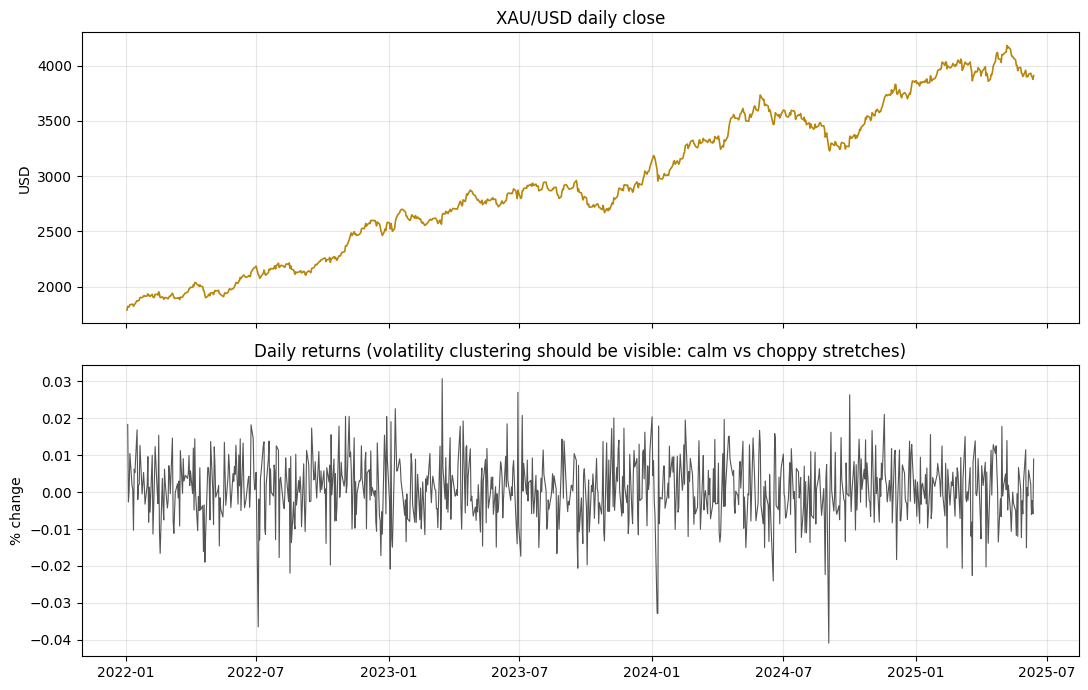

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

axes[0].plot(df.index, df["close"], color="#b8860b", linewidth=1.2)
axes[0].set_title("XAU/USD daily close")
axes[0].set_ylabel("USD")

daily_returns = df["close"].pct_change()
axes[1].plot(df.index, daily_returns, color="#555", linewidth=0.8)
axes[1].set_title("Daily returns (volatility clustering should be visible: calm vs choppy stretches)")
axes[1].set_ylabel("% change")

plt.tight_layout()
plt.show()

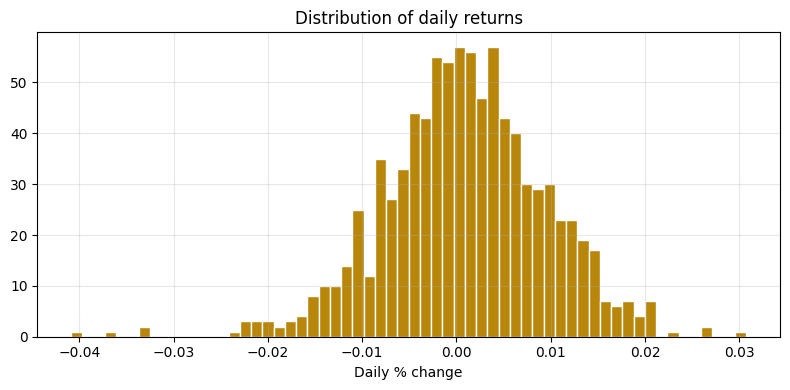

Mean daily return: 0.00091
Std dev of daily return: 0.00858
Skew: -0.291  (real gold returns usually show mild negative skew - occasional sharp drops)


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
daily_returns.dropna().hist(bins=60, ax=ax, color="#b8860b", edgecolor="white")
ax.set_title("Distribution of daily returns")
ax.set_xlabel("Daily % change")
plt.tight_layout()
plt.show()

print(f"Mean daily return: {daily_returns.mean():.5f}")
print(f"Std dev of daily return: {daily_returns.std():.5f}")
print(f"Skew: {daily_returns.skew():.3f}  (real gold returns usually show mild negative skew - occasional sharp drops)")

## Step 3: Feature Engineering

This is the step that actually determines whether the model has a
chance. A Random Forest can't invent information that isn't in its
input columns - it can only find patterns *within* what you hand it. So
the real work of this project lives here, not in the `.fit()` call.

**The features, and the reasoning behind each one:**

| Feature | Why it might matter |
|---|---|
| Lagged returns (1, 3, 5, 10-day) | Short-term momentum / mean-reversion signal |
| Rolling volatility (5, 10, 20-day) | Captures the clustering we just saw - calm periods tend to stay calm |
| RSI (14-day) | Classic overbought/oversold signal |
| Moving average gap (price vs 20-day MA) | How stretched price is from its recent trend |
| Bollinger Band width | Volatility regime, similar spirit to rolling std but scaled differently |
| `high_impact_event` | Macro-event flag - the day of a major USD data release |
| `news_sentiment` | Included deliberately as a **noise feature** - we didn't build a real sentiment pipeline yet, so this is random. Keep this in mind for Step 8; it's a planted test of whether the model (and you) can tell signal from noise. |

**One rule that matters more than any individual feature:** every feature
must be computable using only information available *before* the day
we're predicting. If a "feature" secretly uses today's closing price to
predict today's closing price, that's leakage, and it will make your
model look great and be useless. We'll double-check this at the end of
the step.

In [6]:
feat = pd.DataFrame(index=df.index)

# --- Lagged returns, computed on PAST data only ---
ret = df["close"].pct_change()
feat["return_lag_1d"] = ret.shift(1)
feat["return_lag_3d"] = df["close"].pct_change(3).shift(1)
feat["return_lag_5d"] = df["close"].pct_change(5).shift(1)
feat["return_lag_10d"] = df["close"].pct_change(10).shift(1)

# --- Rolling volatility (std dev of returns), computed on PAST data only ---
feat["volatility_5d"] = ret.rolling(5).std().shift(1)
feat["volatility_10d"] = ret.rolling(10).std().shift(1)
feat["volatility_20d"] = ret.rolling(20).std().shift(1)

# --- RSI (14-day) ---
delta = df["close"].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = (-delta.clip(upper=0)).rolling(14).mean()
rs = gain / loss
feat["rsi_14"] = (100 - (100 / (1 + rs))).shift(1)

# --- Distance from 20-day moving average ---
ma20 = df["close"].rolling(20).mean()
feat["ma20_gap"] = ((df["close"] - ma20) / ma20).shift(1)

# --- Bollinger Band width (20-day, 2 std) ---
std20 = df["close"].rolling(20).std()
bb_upper = ma20 + 2 * std20
bb_lower = ma20 - 2 * std20
feat["bb_width"] = ((bb_upper - bb_lower) / ma20).shift(1)

# --- Macro event flag (yesterday's event, since today's flag would be same-day info) ---
feat["event_yesterday"] = df["high_impact_event"].shift(1)

# --- News sentiment (yesterday's, same logic) ---
feat["sentiment_lag_1d"] = df["news_sentiment"].shift(1)

feat = feat.dropna()
print(f"Feature matrix: {feat.shape[0]} rows x {feat.shape[1]} columns")
feat.head()

Feature matrix: 879 rows x 12 columns


,return_lag_1d,return_lag_3d,return_lag_5d,return_lag_10d,volatility_5d,volatility_10d,volatility_20d,rsi_14,ma20_gap,bb_width,event_yesterday,sentiment_lag_1d
date,,,,,,,,,,,,
2022-02-01,0.001916,0.000422,0.008316,0.022615,0.003103,0.004399,0.006869,77.874501,0.026505,0.080424,0.0,-0.504113
2022-02-02,0.009596,0.008222,0.015383,0.034493,0.004764,0.004675,0.006110,91.873630,0.033219,0.082972,0.0,0.316361
2022-02-03,-0.008153,0.003283,0.001787,0.024099,0.006622,0.005944,0.006491,80.806094,0.022000,0.080547,0.0,0.256829
2022-02-04,0.001348,0.002715,0.001350,0.023349,0.006602,0.005953,0.006479,79.775692,0.020549,0.076948,0.0,0.172518
2022-02-07,-0.005426,-0.012205,-0.000815,0.005077,0.006953,0.005161,0.006464,66.670158,0.013005,0.074248,0.0,-0.243864


**Leakage check, out loud:** every column above is `.shift(1)`'d or
built from `pct_change(n).shift(1)` - meaning every single feature for
"today" only uses information through "yesterday's close." That's the
rule from above, enforced in code, not just promised in a comment. This
is the single most common way a student's model quietly cheats, so it's
worth this much fuss.

## Step 4: Define the Target and Split Time-Aware

**The target:** we predict tomorrow's **percent change** in close, not
the raw price. Raw price is non-stationary (it trends, so a model can
"cheat" by just learning the trend rather than genuine signal); percent
change is roughly stationary and forces the model to actually learn
something about direction and magnitude.

**Why NOT a random train/test split:** a normal `train_test_split` with
`shuffle=True` would let the model train on data from *after* the day
it's being tested on. That's future information leaking into the past -
invisible in your metrics, catastrophic in the real world. Time series
data always gets split chronologically: train on the past, test on data
the model has never seen and that comes strictly after.

In [7]:
target = df["close"].pct_change().shift(-1)  # tomorrow's return
target.name = "target_next_day_return"

data = feat.join(target).dropna()
X = data.drop(columns=["target_next_day_return"])
y = data["target_next_day_return"]

split_idx = int(len(data) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {X_train.index.min().date()} to {X_train.index.max().date()}  ({len(X_train)} rows)")
print(f"Test:  {X_test.index.min().date()} to {X_test.index.max().date()}  ({len(X_test)} rows)")

Train: 2022-02-01 to 2024-10-09  (702 rows)
Test:  2024-10-10 to 2025-06-12  (176 rows)


## Step 5: Baseline Model - the Honesty Check

Before training anything, set a bar the real model has to clear. The
simplest possible forecast for a near-random-walk asset is **"tomorrow's
change = zero"** (i.e., predict no movement) - this is the standard
naive baseline for return prediction. If the Random Forest can't beat
this, that's a real result worth reporting, not something to bury.

In [8]:
baseline_pred = np.zeros(len(y_test))  # naive: predict no change

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print(f"Baseline (predict zero change) - MAE: {baseline_mae:.5f}, RMSE: {baseline_rmse:.5f}")

Baseline (predict zero change) - MAE: 0.00625, RMSE: 0.00792


## Step 6: Train the Random Forest Regressor

A couple of the hyperparameters worth understanding, not just setting:

- **`n_estimators`** - how many trees. More trees = more stable
  predictions (averaging reduces variance) but diminishing returns past
  a few hundred, and slower to train.
- **`max_depth`** - how deep each tree can grow. Left unlimited, trees
  can memorize training noise (overfitting) - especially dangerous on
  financial data, which is mostly noise to begin with. We cap it.
- **`min_samples_leaf`** - minimum data points required in a leaf node.
  Raising this forces the model to generalize instead of carving out a
  leaf for a single weird day.

In [9]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"Random Forest - MAE: {rf_mae:.5f}, RMSE: {rf_rmse:.5f}")
print(f"Baseline      - MAE: {baseline_mae:.5f}, RMSE: {baseline_rmse:.5f}")

improvement = (baseline_mae - rf_mae) / baseline_mae * 100
print(f"\nMAE improvement over baseline: {improvement:.1f}%")

Random Forest - MAE: 0.00618, RMSE: 0.00784
Baseline      - MAE: 0.00625, RMSE: 0.00792

MAE improvement over baseline: 1.0%


## Step 7: Evaluate - Did We Actually Learn Anything?

A single MAE number is easy to over-trust. Plotting predicted vs actual
tells you more honestly what's going on - including whether the model
is just predicting something close to zero every day (which would still
show a decent MAE on a mostly-flat target, without being useful).

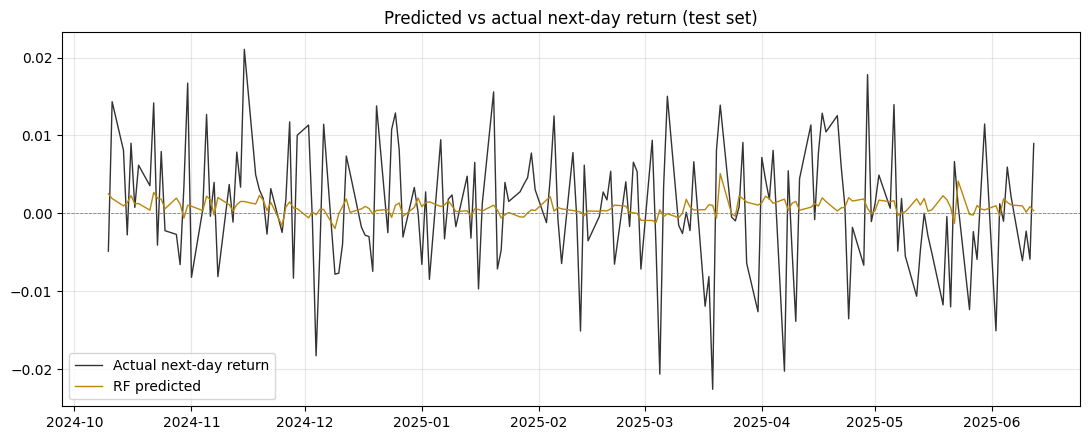

Directional accuracy (predicted the correct up/down sign): 55.7%
(50% is coin-flip. Anything meaningfully above that, on real data, would be a genuine finding.)


In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(y_test.index, y_test.values, label="Actual next-day return", color="#333", linewidth=1)
ax.plot(y_test.index, rf_pred, label="RF predicted", color="#b8860b", linewidth=1)
ax.axhline(0, color="gray", linewidth=0.6, linestyle="--")
ax.set_title("Predicted vs actual next-day return (test set)")
ax.legend()
plt.tight_layout()
plt.show()

# Directional accuracy: did we at least get the SIGN right more than half the time?
direction_correct = (np.sign(rf_pred) == np.sign(y_test)).mean()
print(f"Directional accuracy (predicted the correct up/down sign): {direction_correct:.1%}")
print("(50% is coin-flip. Anything meaningfully above that, on real data, would be a genuine finding.)")

**Reading this honestly:** on synthetic data built mostly from
noise with a small signal component, don't expect a dramatic beat of the
baseline - and that's the right takeaway to internalize now, before you
run this on real gold prices and are tempted to over-read a lucky MAE
number. The discipline is checking *both* the error metric *and*
directional accuracy *and* the plot, not picking whichever one looks
best.

## Step 8: Feature Importance - What Is the Model Actually Using?

This is where the project gets genuinely interesting to write about.
Feature importance tells you what the Random Forest leaned on to make
its splits - and remember, we planted `sentiment_lag_1d` as **pure
random noise**. Watch where it lands.

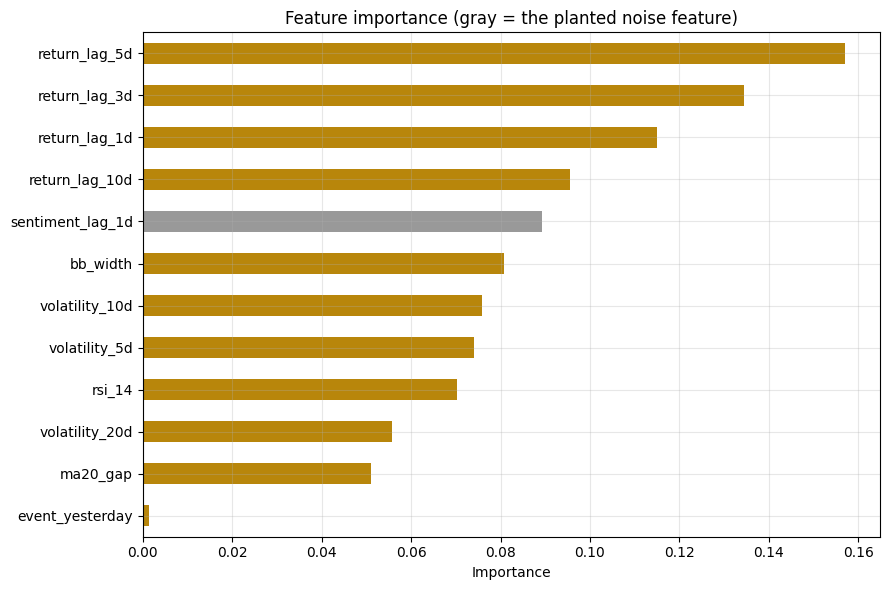

return_lag_5d       0.157027
return_lag_3d       0.134452
return_lag_1d       0.114973
return_lag_10d      0.095469
sentiment_lag_1d    0.089204
bb_width            0.080683
volatility_10d      0.075817
volatility_5d       0.074015
rsi_14              0.070220
volatility_20d      0.055784
ma20_gap            0.051028
event_yesterday     0.001328


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#b8860b" if idx != "sentiment_lag_1d" else "#999" for idx in importances.index]
importances.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Feature importance (gray = the planted noise feature)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).to_string())

**The lesson to actually take from this chart:** if
`sentiment_lag_1d` (gray bar) ranks low, that's the model correctly
telling you it found no relationship - which makes sense, since we
generated it as random noise. That's a genuinely useful sanity check to
run on *any* project: plant a feature you know is meaningless, and
confirm your model doesn't invent a story about it. If a real,
uninformative feature ever ranks *highly* in one of your future
projects, that's usually a sign of a bug (often leakage) rather than a
real discovery.

For the features that *do* rank highly - usually recent volatility and
short-lag returns in this kind of setup - that maps to something real
and explainable: recent volatility tends to persist (that's the
clustering we built in and saw in Step 2), so it's a legitimately
learnable pattern, not a fluke.

## Step 9: Reflection - Limitations, and What Changes With Real Data

Every capstone write-up should end here, not with a triumphant accuracy
number. Some honest limitations for this project, worth stating plainly
in your final report:

1. **This ran on synthetic data.** The pipeline is real; the numbers
   aren't. Swapping in your actual TradingView CSV export is the next
   concrete step - same code, real prices.
2. **Gold is close to a random walk on a 1-day horizon**, even with real
   data. A small, honest edge over the baseline is a believable and
   defensible outcome. A huge edge should make you suspicious of
   leakage before it makes you excited.
3. **The news sentiment feature needs a real pipeline** (NewsAPI/GDELT +
   a sentiment scorer) before it can possibly contribute anything - right
   now it's a deliberately meaningless placeholder.
4. **The macro event flag is a simplification.** A real ForexFactory
   pull would let you distinguish *which* event (NFP vs CPI vs FOMC) and
   whether the actual number beat or missed forecast - "there was an
   event" is much weaker than "CPI came in hotter than expected."
5. **Validation could go further.** A single 80/20 time split is a fine
   starting point; a stronger version of this project would use
   walk-forward validation (retraining on an expanding window and
   testing on each subsequent chunk) to see if performance holds up
   across different market regimes.

None of this is a reason to downgrade the project - it's the difference
between a report that says "look how well this worked" (fragile, often
wrong) and one that says "here's what I built, here's what it actually
found, and here's exactly what I'd do with more time" (the version that
holds up under questioning).